<a href="https://colab.research.google.com/github/1conto/fiap-cap1-ignitionZero/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATIVIDADE INTEGRADORA - RELATÓRIO OPERACIONAL DE PRÉ-DECOLAGEM

[Link GitHub](https://github.com/1conto/fiap-cap1-ignitionZero)

Quando falamos de telemetria de embarcações, principalmente foguetes, estamos tratando de alguns pontos críticos sobre o sucesso e fracasso da missão. Uma missão bem sucedida precisa iniciar com o pé direito, na decolagem.

Ao longo do desenvolvimento do processo da decolagem da missão Aurora 01, a decolagem precisaria ser extremamente bem sucedida, obtendo sucesso em cada mínimo detalhe, e para essa garantia de sucesso, precisaríamos de uma boa definição dos conceitos necessários para a execução da decolagem com segurança, minimizando os erros.

Além disso, a programação embarcada tem papel crucial para garantir que todos os sensores e módulos estejam funcionando corretamente, e no final garante o sucesso da decolagem.

## Organização da telemetria

O sucesso da missão depende totalmente da organização da telemetria e a definição clara das condições necessárias para a decolagem acontecer.

### Variáveis analisadas

O sucesso da missão depende das seguintes variáveis:
* Temperatura interna;
* Temperatura externa;
* Integridade estrutural (0/1);
* Níveis de energia (%);
* Pressão dos tanques;
* Status dos módulos críticos.

Dentre as variáveis, temos que definir inicialmente qual o tipo que elas assumirão.

No caso das temperaturas internas e externas, temos que assumirá valores numéricos definindo um valor da temperatura, nesse caso usaremos o sistema universal, e consideraremos em Celsius (ºC), dessa forma, as temperaturas irá assumir valores numéricos, como a variação milimétrica de temperatura possui pouca variação e pouca relevância, usaremos valores discretos para as variações de temperatura, então o tipo do dado assumirá valores inteiros (int).

Já para níveis de energia, temos uma carga total na bateria que é calculada para ter uma duração total da missão com um valor de sobra. Dessa forma, precisamos analisar como está a carga dela com base na carga total que ela suporta. Analisando esse conceito, iremos trabalhar com valores percentuais, fazendo a $carga_- atual/carga_-total$, dessa forma, por se tratar de resultado de uma divisão, tratamos o nivel de energia como valores numéricos com casas decimais (float).

Analisando os casos de pressão dos tanques, utilizaremos o sistema métrico como definição da análise da pressão (bar). Nesse método, como os sistemas precisam de métricas milimétricas referente a valores, usaremos para armazenar os dados de pressão os valores numéricos com casas decimais (float).

Os outros pontos como Status dos módulos críticos e Integridade Estrutural, o computador precisa realizar alguns testes para verificar se está íntegro ou se é preciso alguma manutenção em módulos e na integridade. Dessa forma, esses testes só podem receber dois valores do teste, True para caso a estrutura não apresente nenhum problema, e False caso apresente algum problema, assim, temos que esse tipo de variável são booleanos. Os booleanos também podem apresentar valores 0 e 1 para representar False e True respectivamente.


### Módulos Críticos

Quando falamos de verificar a integridade dos módulos críticos, temos que existe algumas características reais entre todos esses módulos. Entretanto, o sucesso da missão demanda conhecermos todos os nossos módulos críticos.

Precisamos reservar em algum lugar da memória um direcionamento dos nossos módulos, para isso, criaremos uma lista com nossos módulos críticos.

Os módulos críticos que consideraremos serão:
* O computador de voo (flight_computer);
* Sistema de navegação (navigation_system_status);
* Sistema de controle de atitude (attitude_control);
* Sistema de comunicação (communication_system);
* Sistema de energia (power_system);
* Sistema de propulsão (propulsion_system).

Cada módulo desse tem um papel importante no processo final de decisão, todos os sistemas precisam estar funcionais para que a missão seja um sucesso, dessa forma, todos os sistemas precisam estar funcionais antes de iniciar a decolagem. Dessa forma, precisamos testar todos os módulos para verificarmos se os módulos estão funcionais antes da decolagem.

Vamos iniciar alocando uma lista com todos os módulos críticos, quando algum módulo crítico precisar ser incluído na lista, basta appendarmos esse módulo na lista.


In [105]:
modulos_criticos = [ "flight_computer",
    "navigation_system",
    "attitude_control",
    "communication_system",
    "power_system",
    "propulsion_system"]

## Algoritmo de verificação
Criaremos um fluxograma de um algoritmo capaz de classificar se a decolagem está pronta para ser executada ou se precisaremos abortar a decolagem.

### Fluxograma
![Fluxograma](https://github.com/1conto/fiap-cap1-ignitionZero/blob/main/assets/fluxograma-telemetria.svg?raw=1)

Como a análise dos módulos críticos são similares, precisamos receber valores booleanos a respeito dos dados, podemos tratar os dados referentes a esses módulos em uma classe. Com isso, criamos uma classe de módulos críticos, onde colocaremos as características comuns desses módulos.

In [106]:
import random

class ModulosCriticos:
    def __init__(self, nome):
      self.nome = nome
      self.status = None

    def __str__(self) -> str:
       return {self.nome:self.status}

    def testar_status(self):
        # Define os valores entre True e False com 95% de ser True, e 5% de ser False.
        self.status = random.choices([True, False], weights=[0.95, 0.05])[0]
        return self.status

Usando a mesma lógica do uso de classes para organizarmos os pontos dos Módulos Críticos, usamos também uma classe para organizarmos a estrutura da telemetria. Nessa estrutura de classes, teremos as funções e os atributos que usaremos para a atividade.
Dentre os atributos temos:
* Temperatura Interna e externa: Considerados em °C
* Integridade Estrutural: Avaliado True se estiver integro e False se tiver falhas
* Voltagem bateria: Analisa a tensão da bateria
* Corrente da bateria: Analisa a corrente elétrica em Amperes
* Nivel Bateria: Porcentagem da bateria no momento da leitura
* Capacidade Bateria: Capacidade Total de armazenamento da bateria.
* Energia disponível: Cálculo com os dados para capturarmos a quantidade de energia disponível (kWh)
* Carga Potencia: Valor que vamos precisar durante o período da decolagem
* Perda Energia: Perda esperada de energia no processo da decolagem, avaliado em porcentagem
* Pressão Tanque: Analisa a pressão do momento no tanque
* Modulos: Análise da estrutura dos módulos descritos acima
* Dict Auditoria: Dicionário de motivos explicando cada campo no momento da análise (para auditoria).
* Dict Validações: Dicionário que uso para armazenar os valores das validações de cada campo obrigatório para decolagem.
* Dict Valores: Dicionário para armazenar os valores dos campos que calculamos.
* Decisão Decolagem: String resultante da decisão da telemetria de seguir com o lançamento ou abortar.

Além dos atributos, temos funções de definição de valor para cada campo. Iniciamos cada atributo no valor None e depois associamos os valores, uma vez que não faz sentido definirmos o valor dos atributos já no momento da inicialização da telemetria, visto que um módulo que em um momento inicial estava OK, pode se deteriorar ao longo do processo e não ser mais seguro realizar a decolagem com esse módulo, e devemos abortar a decolagem. Os outros componentes também podem sofrer alterações dos valores.

Além das funções de definição de valores, temos também as funções de validação, onde fazemos as validações se os campos estão em valores seguros para decolagem e autoriza a decolagem ou proíbe. Essas validações altera os valores dos atributos que são dicionários e da decisão de decolagem.

In [169]:
class Telemetria:
    def __init__(self, list_modulos):
        """
        Nessa camada do __init__ iniciamos todos os atributos que vamos precisar para
        o módulo da Telemetria.
        """
        self.temperatura_interna = None   # Possui
        self.temperatura_externa = None   # Possui
        self.integridade_estrutural = None  # Possui
        self.voltagem_bateria = None
        self.corrente_bateria = None
        self.nivel_bateria = None
        self.capacidade_bateria = None
        self.energia_disponivel = None
        self.carga_potencia = None
        self.perda_energia = None
        self.pressao_tanque = None
        self.modulos = [ModulosCriticos(modulo) for modulo in list_modulos]
        self.dict_validacoes = None
        self.dict_auditoria = None
        self.dict_valores = None
        self.decisao_decolagem = None

    @property
    def valores(self):
        return self.dict_valores

    # Funções para definir valores dos módulos
    def testar_todos_modulos(self):
        for modulo in self.modulos:
          modulo.testar_status()
        return self.modulos

    def captura_temperatura_interna(self):      # Está sendo calculada
        # Distribuição normal com média de 24 e desvio de 6, assim, eu aumento a possibilidade de cair entre o intervalo seguro
        self.temperatura_interna = max(-10, min(350, int(random.gauss(24,6))))   # Com essa distribuição, aumento as chances de cair um valor aleatório dentro do limite seguro de lançamento
        return self.temperatura_interna

    def captura_temperatura_externa(self):      # Está sendo calculada
        self.temperatura_externa = max(-80, min(100, int(random.gauss(25,8))))
        return self.temperatura_externa

    def captura_voltagem_bateria(self):       # Adicionada
        # Favor verificar essa distribuição, tentar entender qual distribuição é melhor utilizada
        self.voltagem_bateria = random.uniform(46, 52)
        return self.voltagem_bateria

    def captura_corrente_bateria(self):       # Adicionada
        self.corrente_bateria = random.uniform(20, 120)
        return self.corrente_bateria

    def captura_energy_lvl(self):     # Está sendo calculada
        self.nivel_bateria = random.betavariate(10,1)    # Com essa distribuição aumento as chances de cair entre 80 e 100 de energia.
        return self.nivel_bateria

    def captura_capacidade_bateria(self):     # Adicionada
        self.capacidade_bateria = random.uniform(80, 120)
        return self.capacidade_bateria

    def captura_energia_disponivel(self):     # Adicionada
        self.energia_disponivel = (self.voltagem_bateria * self.capacidade_bateria * self.nivel_bateria) /1000
        return self.energia_disponivel

    def captura_carga_potencia(self):         # Adicionada
        self.carga_potencia = random.uniform(5, 25)
        return self.carga_potencia

    def captura_perda_energia(self):        # Adicionada
        self.perda_energia = random.uniform(2, 8)
        return self.perda_energia

    def captura_pressao_tanque(self):     # Está sendo calculada
        self.pressao_tanque = random.gauss(70,5)
        return self.pressao_tanque

    def captura_integridade_estrutural(self):   # Está sendo calculada
        self.integridade_estrutural = random.choices([True, False], weights=[0.9, 0.1])[0]
        return self.integridade_estrutural

    def captura_infos_telemetria(self):
        self.captura_temperatura_interna()
        self.captura_temperatura_externa()
        self.captura_integridade_estrutural()
        self.captura_energy_lvl()
        self.captura_pressao_tanque()

    def captura_infos_energia(self):
        self.captura_voltagem_bateria()
        self.captura_corrente_bateria()
        self.captura_capacidade_bateria()
        self.captura_carga_potencia()
        self.captura_energia_disponivel()
        self.captura_perda_energia()

    def define_valores_info_energia(self):
        self.captura_infos_energia()
        modulos_energia = ['voltagem_bateria', 'corrente_bateria', 'capacidade_bateria', 'carga_potencia', 'energia_disponivel', 'perda_energia']
        for modulo in modulos_energia:
            valor = getattr(self, modulo)
            self.dict_valores[modulo] = valor


    # Funções de validação
    def validacoes_telemetria(self, valores_seguros):
        self.testar_todos_modulos()
        self.captura_infos_telemetria()
        dict_validacoes = {}
        dict_auditoria = {}
        dict_valores = {}
        for sensor, valor_seguro in valores_seguros.items():
            valor = getattr(self, sensor)
            dict_valores[sensor] = valor
            if sensor == 'modulos':
                dict_validacoes[sensor] = all([modulo.status for modulo in valor])
                dict_valores[sensor] = {modulo.nome: modulo.status for modulo in valor}
                modulos_falhos = [modulo.nome for modulo in valor if not modulo.status]
                dict_auditoria[sensor] = {'valor_atual': all([modulo.status for modulo in valor]), 'regra': f'Os módulos {', '.join(modulos_falhos)}{" não " if len(modulos_falhos)!=0 else ""}estão seguros.'}

            elif isinstance(valor_seguro, dict):
                minimo = valor_seguro['min']
                maximo = valor_seguro['max']
                dict_validacoes[sensor] = minimo <= valor <= maximo
                dict_auditoria[sensor] = {'valor_atual': valor, 'regra': f'{sensor} deve estar entre {minimo} e {maximo}. Valor atual {valor}'}

            elif isinstance(valor_seguro, bool):
                dict_validacoes[sensor] = valor == valor_seguro
                dict_auditoria[sensor] = {'valor_atual': valor, 'regra': f'{sensor} deve ser {valor_seguro}.'}

        self.dict_validacoes = dict_validacoes
        self.dict_auditoria = dict_auditoria
        self.dict_valores = dict_valores
        self.define_valores_info_energia()

    def valida_decolagem(self):
        if all(self.dict_validacoes.values()):
            self.decisao_decolagem = "PRONTO PARA DECOLAR"
        else:
            self.decisao_decolagem = "DECOLAGEM ABORTADA"
        self.dict_valores['Decolagem'] = self.decisao_decolagem
        self.dict_valores['Motivo'] = self.dict_auditoria
        self.dict_valores['Validações'] = self.dict_validacoes
        return self.decisao_decolagem


## Script em Python

Após fazermos a lógica por trás da Telemetria, usamos um dicionário para alimentarmos os valores seguros dos atributos necessários. Dessa forma, garantimos que não existe números mágicos dentro da execução do código e em caso de uma possível mudança nos valores seguros, conseguimos garantir a execução correta do código apenas alterando os valores desse dicionário, é importante esse campo não ser um atributo dentro da camada da classe Telemetria, visto que dependendo do local que vai ocorrer o lançamento, valores seguros para temperatura externa e pressão podem variar. Então, dessa forma, fazemos o código ser reutilizado. Repare que na função validacoes_telemetria onde validamos cada campo, recebemos o dicionário do valor seguro como um parâmetro.

In [170]:
valores_seguros = {
    "temperatura_interna": {"min": 18, "max": 30},
    "temperatura_externa": {"min": 15, "max": 35},
    "nivel_bateria": {"min": 0.8, "max": 1},
    "pressao_tanque": {"min": 60, "max": 80},
    "integridade_estrutural": True,
    "modulos": True
}

Finalizando todo a a definição dos valores dos campos e dos valores seguros, podemos realizar o teste da nossa Telemetria.

In [171]:
telemetria_aurora = Telemetria(modulos_criticos)
telemetria_aurora.validacoes_telemetria(valores_seguros)
telemetria_aurora.valida_decolagem()

'PRONTO PARA DECOLAR'

Podemos ver pelo código acima que a definição do status de autorizar ou proibir a decolagem está funcionando. Entretanto, em casos de abortar, não conseguimos identificar se a decolagem foi um falso positivo ou falso negativo. Pensando nisso, dentro da classe de Telemetria existe um encapsulamento dentro da camada valores, que servirá como um processo de auditoria para entendermos se os valores estão condizendo com o resultado que a função valida_decolagem associou.

In [172]:
valores_telemetria = telemetria_aurora.valores
valores_telemetria

{'temperatura_interna': 25,
 'temperatura_externa': 16,
 'nivel_bateria': 0.9570128878836849,
 'pressao_tanque': 70.05460329286869,
 'integridade_estrutural': True,
 'modulos': {'flight_computer': True,
  'navigation_system': True,
  'attitude_control': True,
  'communication_system': True,
  'power_system': True,
  'propulsion_system': True},
 'voltagem_bateria': 51.66116111144075,
 'corrente_bateria': 66.45888943225265,
 'capacidade_bateria': 94.90559905456395,
 'carga_potencia': 21.05040080912722,
 'energia_disponivel': 4.692170493516725,
 'perda_energia': 6.518690797850115,
 'Decolagem': 'PRONTO PARA DECOLAR',
 'Motivo': {'temperatura_interna': {'valor_atual': 25,
   'regra': 'temperatura_interna deve estar entre 18 e 30. Valor atual 25'},
  'temperatura_externa': {'valor_atual': 16,
   'regra': 'temperatura_externa deve estar entre 15 e 35. Valor atual 16'},
  'nivel_bateria': {'valor_atual': 0.9570128878836849,
   'regra': 'nivel_bateria deve estar entre 0.8 e 1. Valor atual 0.95

## Análise energética

A sustentabilidade elétrica de um lançamento é um dos pilares críticos da telemetria. Para garantir que os sistemas de bordo operem com segurança durante toda a janela de decolagem, implementamos uma lógica de Análise Energética que transforma dados brutos de hardware em indicadores de tempo real (autonomia).

O processo foi modelado para ser resiliente, tratando a energia não apenas como uma reserva estática, mas como um recurso dinâmico sujeito a condições ambientais e operacionais. A lógica segue três etapas fundamentais:

* Determinação da Energia Disponível: O sistema cruza a capacidade_total do banco de baterias com o nivel_bateria atual. Isso evita o uso de "números mágicos" e permite que o software se adapte a diferentes configurações de hardware ou níveis de carga no momento da ativação.

* Fator de Degradação (Perda Energética): Diferente de cálculos teóricos ideais, inserimos a variável perda_energia. Este campo é crucial, pois considera a dissipação térmica e ineficiências do sistema sob carga alta (como ocorre na ignição), resultando na Energia Útil real.

* Projeção de Autonomia: Ao dividir a energia útil pelo consumo (carga_potencia) exigido pelos sistemas de decolagem, o algoritmo gera a Autonomia Inicial em horas. Este dado é o principal indicador para a tomada de decisão: se a autonomia for inferior ao tempo previsto de missão mais a margem de segurança, o lançamento deve ser abortado.

In [173]:
def analise_energetica(telemetria):
    valores = telemetria.valores

    # Garantia mínima
    if valores is None:
        print("Erro: telemetria sem dados.")
        return

    # Pegando os dados
    capacidade_total = valores['capacidade_bateria']   # kWh
    nivel_bateria = valores['nivel_bateria']           # 0 a 1
    consumo = valores['carga_potencia']                # kW
    perda = valores['perda_energia']                   # %

    # Energia total disponível
    energia_total = capacidade_total * nivel_bateria

    # Descontando perdas
    energia_util = energia_total * (1 - perda / 100)

    # Autonomia (horas)
    autonomia = energia_util / consumo

    # Saída
    print("===== ANÁLISE ENERGÉTICA =====")
    print(f"Capacidade Total: {capacidade_total:.2f} kWh")
    print(f"Carga Atual: {nivel_bateria*100:.2f}%")
    print(f"Consumo na Decolagem: {consumo:.2f} kW")
    print(f"Perdas Energéticas: {perda:.2f}%")
    print("---------------------------------")
    print(f"Energia Total: {energia_total:.2f} kWh")
    print(f"Energia Útil: {energia_util:.2f} kWh")
    print(f"Autonomia Inicial: {autonomia:.2f} horas")

    return autonomia

In [174]:
analise_energetica(telemetria_aurora)

===== ANÁLISE ENERGÉTICA =====
Capacidade Total: 94.91 kWh
Carga Atual: 95.70%
Consumo na Decolagem: 21.05 kW
Perdas Energéticas: 6.52%
---------------------------------
Energia Total: 90.83 kWh
Energia Útil: 84.91 kWh
Autonomia Inicial: 4.03 horas


4.033425483093041

## Análise assistida por IA

O primeiro ponto para fazermos uma análise assistida com IA é criar um banco de ocorrências ao longo das execuções, salvaremos esses pontos em um dataframe. E precisamos de várias ocorrências desse modelo para conseguirmos treinar o nosso modelo. Com isso, irei gerar um dataframe com essas ocorrências.

In [175]:
import pandas as pd

numero_ocorrencias = 1000
telemetria_geracao = Telemetria(modulos_criticos)
list_valores = []
for i in range(numero_ocorrencias):
    telemetria_geracao.validacoes_telemetria(valores_seguros)
    telemetria_geracao.valida_decolagem()
    list_valores.append(telemetria_geracao.valores)

df_ocorrencias = pd.DataFrame(list_valores)
df_ocorrencias.head(10)

,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,modulos,voltagem_bateria,corrente_bateria,capacidade_bateria,carga_potencia,energia_disponivel,perda_energia,Decolagem,Motivo,Validações
0,25,27,0.810819,78.448048,True,"{'flight_computer': True, 'navigation_system':...",48.170759,52.036156,115.482728,7.534236,4.510498,6.184672,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 25, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
1,31,29,0.995034,70.828700,True,"{'flight_computer': True, 'navigation_system':...",50.329665,51.633708,103.545534,8.919592,5.185532,2.409882,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 31, 'r...","{'temperatura_interna': False, 'temperatura_ex..."
2,21,24,0.925731,68.215214,True,"{'flight_computer': True, 'navigation_system':...",48.919016,28.390167,115.201410,18.846576,5.216995,5.995832,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 21, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
3,27,18,0.982576,74.188061,False,"{'flight_computer': True, 'navigation_system':...",46.252441,90.170613,100.712717,13.431216,4.577046,7.152377,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 27, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
4,22,32,0.991110,79.462135,True,"{'flight_computer': False, 'navigation_system'...",50.462037,110.691702,119.208602,8.800576,5.962029,2.663694,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 22, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
5,22,19,0.965802,64.787495,True,"{'flight_computer': True, 'navigation_system':...",47.628054,39.956149,81.784793,13.456870,3.762040,6.429650,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 22, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
6,25,26,0.728257,64.783193,True,"{'flight_computer': True, 'navigation_system':...",51.090976,33.077648,100.263431,20.941134,3.730536,2.734174,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 25, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
7,24,23,0.857874,64.394706,True,"{'flight_computer': True, 'navigation_system':...",49.210671,45.611009,118.654841,9.587805,5.009197,2.955977,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 24, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
8,27,15,0.995553,67.817246,False,"{'flight_computer': True, 'navigation_system':...",49.586353,47.767486,80.955449,19.745233,3.996435,4.561336,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 27, 'r...","{'temperatura_interna': True, 'temperatura_ext..."
9,35,12,0.939217,70.838079,True,"{'flight_computer': True, 'navigation_system':...",49.067652,115.695152,87.738161,22.595908,4.043427,6.468926,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 35, 'r...","{'temperatura_interna': False, 'temperatura_ex..."


Podemos perceber que os módulos são de importância para definirmos sobre a decolagem. Então, não faz sentido mantermos a coluna módulos descrita apenas como esse dicionário de nome e valor. Precisamos expandir esses valores.

In [176]:
df_modulos_expandido = df_ocorrencias['modulos'].apply(pd.Series)
df_ocorrencias = pd.concat([df_ocorrencias.drop('modulos', axis=1), df_modulos_expandido], axis=1)
df_ocorrencias.head()

,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,voltagem_bateria,corrente_bateria,capacidade_bateria,carga_potencia,energia_disponivel,perda_energia,Decolagem,Motivo,Validações,flight_computer,navigation_system,attitude_control,communication_system,power_system,propulsion_system
0,25,27,0.810819,78.448048,True,48.170759,52.036156,115.482728,7.534236,4.510498,6.184672,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 25, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
1,31,29,0.995034,70.828700,True,50.329665,51.633708,103.545534,8.919592,5.185532,2.409882,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 31, 'r...","{'temperatura_interna': False, 'temperatura_ex...",True,True,True,True,True,True
2,21,24,0.925731,68.215214,True,48.919016,28.390167,115.201410,18.846576,5.216995,5.995832,PRONTO PARA DECOLAR,"{'temperatura_interna': {'valor_atual': 21, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
3,27,18,0.982576,74.188061,False,46.252441,90.170613,100.712717,13.431216,4.577046,7.152377,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 27, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
4,22,32,0.991110,79.462135,True,50.462037,110.691702,119.208602,8.800576,5.962029,2.663694,DECOLAGEM ABORTADA,"{'temperatura_interna': {'valor_atual': 22, 'r...","{'temperatura_interna': True, 'temperatura_ext...",False,True,True,True,True,True


Para execução de um bom código de análise de IA precisamos garantir que os dados de fato façam sentido com o que deveria ser usado para treinarmos nosso modelo. Iniciaremos então nossa Análise Exploratória dos Dados (EDA).
### Análise exploratória dos dados


Analisando os pontos referentes ao DataFrame, precisamos realizar uma classificação dos dados entre Pronto para decolar ou abortar decolagem. Vamos inicialmente alterar os valores da coluna Decolagem, assumindo valores de 1 para PRONTO PARA DECOLAR e 0 para DECOLAGEM ABORTADA.

In [177]:
df_ocorrencias['Decolagem'] = df_ocorrencias['Decolagem'].replace({"DECOLAGEM ABORTADA": 0, "PRONTO PARA DECOLAR": 1})
df_ocorrencias.head()

/tmp/ipykernel_4175/2830728088.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ocorrencias['Decolagem'] = df_ocorrencias['Decolagem'].replace({"DECOLAGEM ABORTADA": 0, "PRONTO PARA DECOLAR": 1})


,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,voltagem_bateria,corrente_bateria,capacidade_bateria,carga_potencia,energia_disponivel,perda_energia,Decolagem,Motivo,Validações,flight_computer,navigation_system,attitude_control,communication_system,power_system,propulsion_system
0,25,27,0.810819,78.448048,True,48.170759,52.036156,115.482728,7.534236,4.510498,6.184672,1,"{'temperatura_interna': {'valor_atual': 25, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
1,31,29,0.995034,70.828700,True,50.329665,51.633708,103.545534,8.919592,5.185532,2.409882,0,"{'temperatura_interna': {'valor_atual': 31, 'r...","{'temperatura_interna': False, 'temperatura_ex...",True,True,True,True,True,True
2,21,24,0.925731,68.215214,True,48.919016,28.390167,115.201410,18.846576,5.216995,5.995832,1,"{'temperatura_interna': {'valor_atual': 21, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
3,27,18,0.982576,74.188061,False,46.252441,90.170613,100.712717,13.431216,4.577046,7.152377,0,"{'temperatura_interna': {'valor_atual': 27, 'r...","{'temperatura_interna': True, 'temperatura_ext...",True,True,True,True,True,True
4,22,32,0.991110,79.462135,True,50.462037,110.691702,119.208602,8.800576,5.962029,2.663694,0,"{'temperatura_interna': {'valor_atual': 22, 'r...","{'temperatura_interna': True, 'temperatura_ext...",False,True,True,True,True,True


Agora um outro ponto que temos para conseguirmos executar corretamente o algoritmo de classificação é transformarmos os tipos das colunas em tipos numéricos. Logo, primeiro precisamos entender os tipos de dados que são inseridos dentro de cada coluna. Para isso, podemos usar o dtypes.

In [178]:
df_ocorrencias.dtypes

,0
temperatura_interna,int64
temperatura_externa,int64
nivel_bateria,float64
pressao_tanque,float64
integridade_estrutural,bool
voltagem_bateria,float64
corrente_bateria,float64
capacidade_bateria,float64
carga_potencia,float64
energia_disponivel,float64


Analisando as colunas, podemos perceber que temos as colunas classificadas como int64, float64, bool e object. O único caso de object não é relevante para o treinamento do modelo que é a coluna de Motivo.  
Essa coluna de Motivo está sendo inserida apenas para conseguirmos analisar o que em cada momento de análise está sendo analisado, servindo de base para uma possível auditoria.  
Fora essa coluna object temos as colunas booleanas, assim, podemos fazer um script que altera os valores dessas colunas para numéricas, alterando 0 para False e 1 para True.

In [179]:
for columns in df_ocorrencias.columns:
    if df_ocorrencias[columns].dtype == 'bool':
        df_ocorrencias[columns] = df_ocorrencias[columns].astype(int)
df_ocorrencias.head()

,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,voltagem_bateria,corrente_bateria,capacidade_bateria,carga_potencia,energia_disponivel,perda_energia,Decolagem,Motivo,Validações,flight_computer,navigation_system,attitude_control,communication_system,power_system,propulsion_system
0,25,27,0.810819,78.448048,1,48.170759,52.036156,115.482728,7.534236,4.510498,6.184672,1,"{'temperatura_interna': {'valor_atual': 25, 'r...","{'temperatura_interna': True, 'temperatura_ext...",1,1,1,1,1,1
1,31,29,0.995034,70.828700,1,50.329665,51.633708,103.545534,8.919592,5.185532,2.409882,0,"{'temperatura_interna': {'valor_atual': 31, 'r...","{'temperatura_interna': False, 'temperatura_ex...",1,1,1,1,1,1
2,21,24,0.925731,68.215214,1,48.919016,28.390167,115.201410,18.846576,5.216995,5.995832,1,"{'temperatura_interna': {'valor_atual': 21, 'r...","{'temperatura_interna': True, 'temperatura_ext...",1,1,1,1,1,1
3,27,18,0.982576,74.188061,0,46.252441,90.170613,100.712717,13.431216,4.577046,7.152377,0,"{'temperatura_interna': {'valor_atual': 27, 'r...","{'temperatura_interna': True, 'temperatura_ext...",1,1,1,1,1,1
4,22,32,0.991110,79.462135,1,50.462037,110.691702,119.208602,8.800576,5.962029,2.663694,0,"{'temperatura_interna': {'valor_atual': 22, 'r...","{'temperatura_interna': True, 'temperatura_ext...",0,1,1,1,1,1


Após finalizarmos a correção dos dados, podemos iniciar o processo de análise para conseguirmos treinar nosso modelo melhor. Essa análise consegue nos dar uma noção prévia de correlação entre nossos parâmetros.

In [180]:
df_ocorrencias['Decolagem'].value_counts(normalize = True)

,proportion
Decolagem,
0,0.675
1,0.325


Vamos iniciar retirando colunas que não são usadas no nosso processo para definir o status da decolagem. Esse ponto de retirarmos as colunas que não utilizamos no processo é importante para não termos uma correlação espúria e termos um overfitting nos nossos dados. Após correlacionar variáveis que não possuem valores de causa e efeito. Nesse momento, vou transformar o $df_-ocorrencias$ em um $df_-amostra$ filtrando as colunas que usaremos no processo.

In [181]:
df_ocorrencias.columns

Index(['temperatura_interna', 'temperatura_externa', 'nivel_bateria',
       'pressao_tanque', 'integridade_estrutural', 'voltagem_bateria',
       'corrente_bateria', 'capacidade_bateria', 'carga_potencia',
       'energia_disponivel', 'perda_energia', 'Decolagem', 'Motivo',
       'Validações', 'flight_computer', 'navigation_system',
       'attitude_control', 'communication_system', 'power_system',
       'propulsion_system'],
      dtype='object')

In [182]:
df_amostra = df_ocorrencias[['temperatura_interna', 'temperatura_externa', 'nivel_bateria',
                  'pressao_tanque', 'integridade_estrutural', 'flight_computer',
                  'navigation_system', 'attitude_control', 'communication_system',
                  'power_system', 'propulsion_system', 'Decolagem'
              ]]
df_amostra.head()

,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,flight_computer,navigation_system,attitude_control,communication_system,power_system,propulsion_system,Decolagem
0,25,27,0.810819,78.448048,1,1,1,1,1,1,1,1
1,31,29,0.995034,70.828700,1,1,1,1,1,1,1,0
2,21,24,0.925731,68.215214,1,1,1,1,1,1,1,1
3,27,18,0.982576,74.188061,0,1,1,1,1,1,1,0
4,22,32,0.991110,79.462135,1,0,1,1,1,1,1,0


Após o filtro das colunas que usaremos, precisamos analisar como está a divisão dos nossos dados. Não podemos ter uma divisão desigual dos nossos casos de decolagem, para não acontecer overfitting nos nossos sistemas.

In [183]:
df_amostra['Decolagem'].value_counts(normalize=True)

,proportion
Decolagem,
0,0.675
1,0.325


Conseguimos observar que os casos de abortar uma missão e pronta para decolagem estão com distribuições similares. Vamos aproveitar e analisar se temos alguma instância na telemetria que está dando maiores problemas e está nos retornando mais falhas, para percebermos se nos nossos dados de treinamento possui alguma variável que tem um coeficiente angular que pode ser superestimada no modelo.

In [184]:
df_abortar = df_ocorrencias[df_ocorrencias['Decolagem'] == 0]

In [185]:
a = df_abortar['Validações'].apply(pd.Series)

In [186]:
for column in a.columns:
    print(a[column].value_counts(normalize=True))

temperatura_interna
True     0.574815
False    0.425185
Name: proportion, dtype: float64
temperatura_externa
True     0.675556
False    0.324444
Name: proportion, dtype: float64
nivel_bateria
True     0.842963
False    0.157037
Name: proportion, dtype: float64
pressao_tanque
True     0.952593
False    0.047407
Name: proportion, dtype: float64
integridade_estrutural
True     0.859259
False    0.140741
Name: proportion, dtype: float64
modulos
True     0.616296
False    0.383704
Name: proportion, dtype: float64


Podemos perceber, que na maior parte dos casos, as instâncias estão sendo avaliadas como sucedidas, entretanto, temos os Módulos que estão sendo avaliados com 45.9% de falhas. Mas como essa validação dos módulos engloba vários módulos críticos, vamos separar esses módulos para cada módulo em si nos nossos dados de treinamento, então precisamos fazer também uma análise de distrubuição dentro dos módulos.

In [187]:
for modulo in modulos_criticos:
    print(df_amostra[modulo].value_counts(normalize=True))

flight_computer
1    0.955
0    0.045
Name: proportion, dtype: float64
navigation_system
1    0.95
0    0.05
Name: proportion, dtype: float64
attitude_control
1    0.939
0    0.061
Name: proportion, dtype: float64
communication_system
1    0.958
0    0.042
Name: proportion, dtype: float64
power_system
1    0.946
0    0.054
Name: proportion, dtype: float64
propulsion_system
1    0.954
0    0.046
Name: proportion, dtype: float64


Na célula acima, conseguimos perceber que todos estão com distribuições semelhantes, o que não dá indícios de uma possível supervalorização de algum parâmetro dentro dos módulos.

A partir daqui, podemos iniciar nossos treinamentos do modelo.

### Treinamento do modelo

Dentro dos pontos que precisamos realizar no modelo de reconhecimento de anomalias e um modelo de classificação entre Decolagens executadas e decolagens não executadas.

In [188]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

### Modelo de classificação supervisionada.

Para realizarmos as nossas análises de classificação supervisionada, precisamos classificar entre decolagens autorizadas e abortadas. Dessa forma, iremos utilizar do modelo de Random Forest para classificarmos dentre as decolagens, usaremos a coluna Decolagem para ser o ponto supervisionado do nosso modelo.  
Dessa forma, precisamos separar a parte de amostra e a parte de supervisionado, para conseguirmos separar entre amostra de treinamento e de teste.

In [189]:
X = df_amostra.drop("Decolagem", axis=1)
y = df_amostra["Decolagem"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

Vamos iniciar realizando as nossas predições utilizando o modelo de Random Forest e já testando e adicionando informações sobre a matriz de confusão. A escolha do modelo veio uma vez que a lógica de decolagem autorizada ou abortada, vem de uma série de lógicas entre os valores, e precisamos que todas as lógicas estejam corretas. Dessa forma, teremos como se fosse várias árvores binárias e encontraremos o modelo que aproxima nossa lógica de classificação.

In [190]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       131
           1       0.97      1.00      0.99        69

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



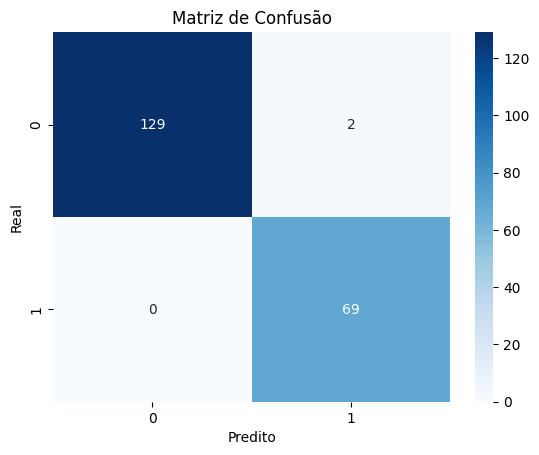

In [191]:
import seaborn as sns
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

Nosso modelo de reconhecimento conseguiu incorporar bem o ponto de prever as decolagens abortadas que precisamos reconhecer. Dessa forma, podemos partir para o reconhecimento de anomalias.

### Modelo de reconhecimento de anomalias.

Dentro do nosso reconhecimento de anomalias, podemos utilizar de um modelo de reconhecimento de outliers que é o Isolation Forest. Esse modelo vai criando alguns vínculos utilizando algumas árvores binárias para reconhecer padrões dentro dos dados. Iniciamos adicionando manualmente algumas anomalias dentro do nosso dataset de testes.

In [192]:
# Base de treino (somente dados normais)
features = [
    'temperatura_interna', 'temperatura_externa', 'nivel_bateria',
    'pressao_tanque', 'integridade_estrutural', 'flight_computer',
    'navigation_system', 'attitude_control', 'communication_system',
    'power_system', 'propulsion_system'
]

X_normal = df_amostra[features].copy()

# Split simples para treino/teste no mesmo estilo do notebook
X_train = X_normal.sample(frac=0.7, random_state=42)
X_test_base = X_normal.drop(X_train.index).copy()

# Injeção manual de anomalias no teste
fracao_anomalias = 0.08
qtd_anomalias = max(1, int(len(X_test_base) * fracao_anomalias))
idx_anomalias = X_test_base.sample(n=qtd_anomalias, random_state=42).index

X_test_anomalo = X_test_base.copy()
X_test_anomalo.loc[idx_anomalias, 'temperatura_interna'] = 130
X_test_anomalo.loc[idx_anomalias, 'temperatura_externa'] = -150
X_test_anomalo.loc[idx_anomalias, 'nivel_bateria'] = 0.05
X_test_anomalo.loc[idx_anomalias, 'pressao_tanque'] = 160

# Rótulo real apenas para validação do experimento
# 0 = normal, 1 = anomalia
y_real = pd.Series(0, index=X_test_anomalo.index)
y_real.loc[idx_anomalias] = 1

print(f"Total teste: {len(X_test_anomalo)}")
print(f"Anomalias manuais injetadas: {int(y_real.sum())}")


Total teste: 300
Anomalias manuais injetadas: 24


In [198]:
# Treinando o Isolation Forest
if_model = IsolationForest(contamination=0.08, random_state=42)
if_model.fit(X_train)

# Predição: sklearn retorna 1 (normal) e -1 (anomalia)
pred_raw = if_model.predict(X_test_anomalo)
y_pred = pd.Series((pred_raw == -1).astype(int), index=X_test_anomalo.index)
print("=== Isolation Forest ===")
print(classification_report(y_real, y_pred, digits=4))
print("Matriz de confusão [normal, anomalia]:")
print(confusion_matrix(y_real, y_pred))

anomalias_detectadas = int((y_real & y_pred).sum())
print(f"Anomalias detectadas: {anomalias_detectadas}/{int(y_real.sum())}")

=== Isolation Forest ===
              precision    recall  f1-score   support

           0     1.0000    0.9348    0.9663       276
           1     0.5714    1.0000    0.7273        24

    accuracy                         0.9400       300
   macro avg     0.7857    0.9674    0.8468       300
weighted avg     0.9657    0.9400    0.9472       300

Matriz de confusão [normal, anomalia]:
[[258  18]
 [  0  24]]
Anomalias detectadas: 24/24


Diante dos nossos dados adicionados manualmente, conseguimos reparar que conseguimos capturar as anomalias capturadas pelo modelo, além disso, pegamos também algumas anomalias naturais que podem estar acontecendo, como valores muito alto ou muito baixo de algum parâmetro, isso aparece para nós como possível falso positivo.

Podemos perceber que nossas detecções de anomalias também estão conseguindo detectar os nossos outliers adicionados manualmente, sendo que tivemos que fazer algumas alterações para conseguirmos capturar os pontos relevantes. Agora com nossos modelos treinados, conseguimos realizar alguma análise do risco de cada decolagem.

### Análise de risco

Para nossa análise de risco, vamos precisar analisar os pontos referentes a nossa lógica de regras para permitir a decolagem, e também o que está sendo decidido pela Inteligência Artificial com alguns pesos. Vamos utilizar 60% de peso das regras e 40% da decisão da IA.

In [199]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def analisar_risco_regras(linha, valores_seguros, modulos):
    risco = 0
    sugestoes = []

    def risco_continuo(valor, min_v, max_v):
        if valor < min_v or valor > max_v:
            return 1.0
        margem = min(valor - min_v, max_v - valor)
        faixa = (max_v - min_v) / 2
        return 1 - (margem / faixa)

    # Temperatura interna
    r = risco_continuo(linha["temperatura_interna"], valores_seguros["temperatura_interna"].get("min"), valores_seguros["temperatura_interna"].get("max"))
    risco += 0.2 * r
    if linha["temperatura_interna"] > 28:
        sugestoes.append("Alta temperatura interna: ativar resfriamento.")

    # Temperatura externa
    r = risco_continuo(linha["temperatura_externa"], valores_seguros["temperatura_externa"].get("min"), valores_seguros["temperatura_externa"].get("max"))
    risco += 0.1 * r

    # Bateria
    r = risco_continuo(linha["nivel_bateria"], valores_seguros["nivel_bateria"].get("min"), valores_seguros["nivel_bateria"].get("max"))
    risco += 0.3 * r
    if linha["nivel_bateria"] < 0.9:
        sugestoes.append("Bateria abaixo do ideal: reduzir consumo.")

    # Pressão
    r = risco_continuo(linha["pressao_tanque"], valores_seguros["pressao_tanque"].get("min"), valores_seguros["pressao_tanque"].get("max"))
    risco += 0.2 * r
    if linha["pressao_tanque"] < 65 or linha["pressao_tanque"] > 75:
        sugestoes.append("Pressão instável: recalibrar.")

    # Estrutura
    if linha["integridade_estrutural"] != valores_seguros["integridade_estrutural"]:
        risco += 1
        sugestoes.append("Falha estrutural crítica.")

    # Módulos
    if all(linha[modulos]) != valores_seguros["modulos"]:
        risco += 1
        sugestoes.append("Falha em módulos críticos.")

    return min(risco, 1), sugestoes

def calcular_risco_iforest(model, X):
    scores = model.decision_function(X)

    min_score = scores.min()
    max_score = scores.max()

    range_score = max_score - min_score

    if range_score < 1e-10:  # tolerância numérica
        return np.full_like(scores, 0.5)  # risco neutro

    risco = 1 - (scores - scores.min()) / range_score

    return risco

def analisar_linha(linha, model, valores_seguros, modulos):
    # risco por regras
    risco_regras, sugestoes = analisar_risco_regras(linha, valores_seguros, modulos)

    # risco por modelo
    X = pd.DataFrame([linha])
    risco_iforest = calcular_risco_iforest(model, X)[0]

    # combinação
    risco_total = 0.4 * risco_iforest + 0.6 * risco_regras

    # classificação
    if risco_total > 0.7:
        classe = "CRITICO"
    elif risco_total > 0.4:
        classe = "SUSPEITO"
    else:
        classe = "NORMAL"

    return {
        "risco_regras": round(risco_regras, 3),
        "risco_iforest": round(risco_iforest, 3),
        "risco_total": round(risco_total, 3),
        "classificacao": classe,
        "sugestoes": sugestoes
    }

def aplicar_modelo(df, model, valores_seguros, modulos):
    resultados = df.apply(lambda row: analisar_linha(row, model, valores_seguros, modulos), axis=1)
    df["risco_regras"] = resultados.apply(lambda x: x["risco_regras"])
    df["risco_iforest"] = resultados.apply(lambda x: x["risco_iforest"])
    df["risco_total"] = resultados.apply(lambda x: x["risco_total"])
    df["classificacao"] = resultados.apply(lambda x: x["classificacao"])
    df["sugestoes"] = resultados.apply(lambda x: x["sugestoes"])

    return df

aplicar_modelo(df_amostra.drop('Decolagem', axis=1), if_model, valores_seguros=valores_seguros, modulos = modulos_criticos)

,temperatura_interna,temperatura_externa,nivel_bateria,pressao_tanque,integridade_estrutural,flight_computer,navigation_system,attitude_control,communication_system,power_system,propulsion_system,risco_regras,risco_iforest,risco_total,classificacao,sugestoes
0,25,27,0.810819,78.448048,1,1,1,1,1,1,1,0.490,0.5,0.494,SUSPEITO,"[Bateria abaixo do ideal: reduzir consumo., Pr..."
1,31,29,0.995034,70.828700,1,1,1,1,1,1,1,0.542,0.5,0.525,SUSPEITO,[Alta temperatura interna: ativar resfriamento.]
2,21,24,0.925731,68.215214,1,1,1,1,1,1,1,0.223,0.5,0.334,NORMAL,[]
3,27,18,0.982576,74.188061,0,1,1,1,1,1,1,1.000,0.5,0.800,CRITICO,[Falha estrutural crítica.]
4,22,32,0.991110,79.462135,1,0,1,1,1,1,1,1.000,0.5,0.800,CRITICO,"[Pressão instável: recalibrar., Falha em módul..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,15,26,0.961566,75.542988,1,1,1,0,1,1,1,1.000,0.5,0.800,CRITICO,"[Pressão instável: recalibrar., Falha em módul..."
996,29,30,0.862217,72.745529,0,1,1,1,1,1,1,1.000,0.5,0.800,CRITICO,[Alta temperatura interna: ativar resfriamento...
997,21,12,0.906002,71.701612,1,1,1,1,1,1,1,0.252,0.5,0.351,NORMAL,[]
998,25,26,0.971949,64.393740,1,1,1,1,1,1,1,0.371,0.5,0.423,SUSPEITO,[Pressão instável: recalibrar.]


Então, com esse último ponto, conseguimos classificar os riscos com base em uma possível anomalia dos nossos dados e também de uma proximidade dos dados da telemetria com os valores seguros, de forma que se estivermos tendo alguma decolagem que no momento está sendo autorizada mas com alguma possível complicação que pode acontecer nos próximos segundos seja analisada com base no nível de segurança.

## Reflexão crítica



A exploração espacial costuma ser vista como um dos maiores símbolos de progresso da humanidade, mas, quando analisada de forma mais crítica, levanta uma série de questões que vão muito além da tecnologia. Não se trata apenas de chegar mais longe no universo, mas de entender como, por que e para quem esse avanço acontece.

Do ponto de vista ético, o problema central não é simplesmente avaliar se explorar o espaço é certo ou errado, mas sim quem tem o poder de tomar essas decisões. Hoje, esse controle está concentrado em poucas nações e em grandes organizações, como a NASA, além de empresas privadas como a SpaceX. Isso cria um desequilíbrio evidente, já que decisões com impacto potencialmente global acabam sendo tomadas por um grupo limitado. Além disso, surgem preocupações concretas, como o aumento do lixo espacial, o risco de contaminação de outros corpos celestes e até a possibilidade de uso militar do espaço. Nesse cenário, a ética deixa de ser um conceito abstrato e passa a exigir regras claras, responsabilidade real e algum tipo de governança internacional mais eficaz.

No campo social, a exploração espacial também carrega um paradoxo difícil de ignorar. Ao mesmo tempo em que bilhões são investidos em missões fora da Terra, ainda existem problemas básicos aqui que continuam sem solução. Isso levanta uma questão direta sobre prioridades. Por outro lado, não dá para negar que muitos avanços tecnológicos vindos dessas iniciativas já melhoraram a vida cotidiana — desde sistemas de comunicação até monitoramento climático. O problema é que esses benefícios não chegam de forma igual para todos. Com a entrada cada vez maior do setor privado, o espaço também começa a ser tratado como um novo mercado, o que traz riscos como concentração de poder, exploração comercial excessiva e até a ampliação de disputas geopolíticas para fora do planeta.

Já a questão da sustentabilidade tecnológica mostra que o modelo atual ainda está longe do ideal. Cada lançamento de foguete gera impactos ambientais e contribui para o acúmulo de detritos em órbita, que podem causar colisões e comprometer futuras missões. Iniciativas como o uso de foguetes reutilizáveis impulsionadas por empresas como a SpaceX representam um avanço importante, mas ainda são insuficientes diante do problema maior. O ponto mais crítico é que existe o risco de repetir no espaço os mesmos erros cometidos na Terra: exploração intensiva sem planejamento de longo prazo. Sem uma mudança de abordagem, focada em responsabilidade e preservação, a expansão para outros ambientes pode apenas ampliar problemas que já existem.

No fim, a exploração espacial não é só uma questão de capacidade tecnológica, mas de maturidade coletiva. Avançar sem refletir sobre as consequências pode transformar uma conquista em um novo tipo de problema. Por isso, discutir ética, impacto social e sustentabilidade não é um detalhe é o que define se esse avanço será realmente um progresso ou apenas uma repetição, em outra escala, dos mesmos erros já conhecidos.